In [61]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# Suppress FutureWarnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [63]:
# Load the dataset
data = pd.read_csv('Electric_Vehicle_Population_Size_History_By_County_.csv')



In [64]:
# Data cleaning and preprocessing
columns_to_clean = [
    "Battery Electric Vehicles (BEVs)", 
    "Plug-In Hybrid Electric Vehicles (PHEVs)", 
    "Electric Vehicle (EV) Total", 
    "Non-Electric Vehicle Total", 
    "Total Vehicles"
]


In [65]:
 #Clean and convert numeric columns
def clean_and_convert(df, columns):
    for col in columns:
        df[col] = df[col].replace(",", "", regex=True).astype(float)
    return df

data = clean_and_convert(data, columns_to_clean)


In [66]:
# Drop rows with missing values in key columns
data = data.dropna(subset=["County", "State"])

In [67]:
# Replace infinite values with NaN and drop them
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

In [68]:
# Feature selection
features = [
    "Battery Electric Vehicles (BEVs)", 
    "Plug-In Hybrid Electric Vehicles (PHEVs)", 
    "Percent Electric Vehicles", 
    "Total Vehicles"
]
X = data[features]


In [69]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [70]:
# Add a dummy target column for analysis
data['Target'] = (data["Percent Electric Vehicles"] > data["Percent Electric Vehicles"].median()).astype(int)

In [71]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, data['Target'], test_size=0.3, random_state=42)

In [72]:
# Train a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [73]:
# Make predictions and evaluate the model
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3097
           1       1.00      1.00      1.00      3123

    accuracy                           1.00      6220
   macro avg       1.00      1.00      1.00      6220
weighted avg       1.00      1.00      1.00      6220

Accuracy: 1.00


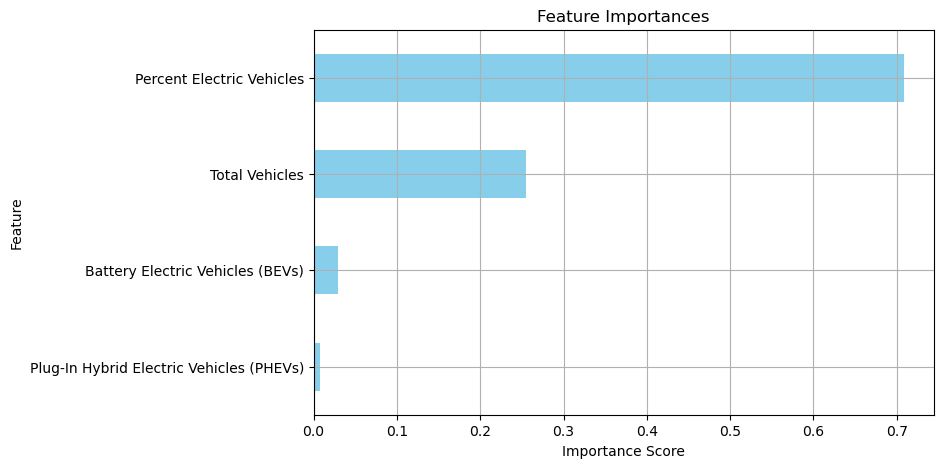

In [74]:
# Visualize feature importances
plt.figure(figsize=(8, 5))
feature_importances = pd.Series(rf.feature_importances_, index=features)
feature_importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid()
plt.show()



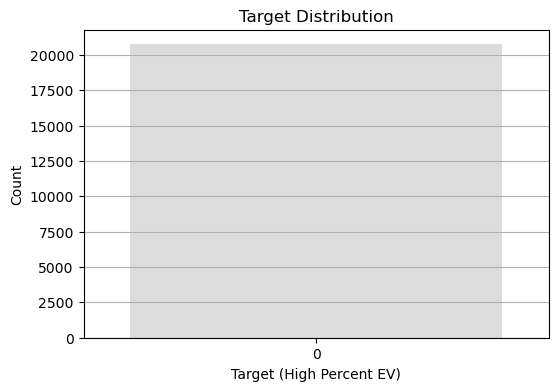

In [75]:
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data['Target'], palette="coolwarm")
plt.title("Target Distribution")
plt.xlabel("Target (High Percent EV)")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

In [76]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

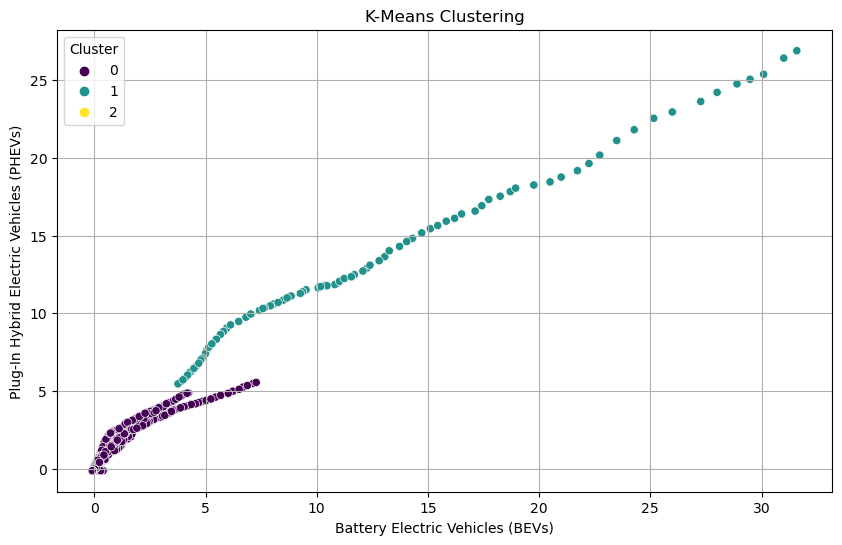

In [77]:
# Visualize clustering results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=data['Cluster'], palette="viridis")
plt.title("K-Means Clustering")
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(title="Cluster")
plt.grid()
plt.show()